C:\anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Found 58154 images belonging to 49 classes.
Found 14517 images belonging to 49 classes.
🚀 Phase 1: Initial Training Started
Epoch 1/10
 334/1818 ━━━━━━━━━━━━━━━━━━━━ 49:55 2s/step - accuracy: 0.2158 - loss: 3.4684

C:\Users\patta\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1818/1818 ━━━━━━━━━━━━━━━━━━━━ 4371s 2s/step - accuracy: 0.2430 - loss: 3.2851 - val_accuracy: 0.2432 - val_loss: 3.1607
Epoch 2/10
1818/1818 ━━━━━━━━━━━━━━━━━━━━ 4612s 3s/step - accuracy: 0.2490 - loss: 3.1785 - val_accuracy: 0.2495 - val_loss: 3.1171
Epoch 3/10
1818/1818 ━━━━━━━━━━━━━━━━━━━━ 4063s 2s/step - accuracy: 0.2515 - loss: 3.1409 - val_accuracy: 0.2514 - val_loss: 3.0940
Epoch 4/10
1818/1818 ━━━━━━━━━━━━━━━━━━━━ 3983s 2s/step - accuracy: 0.2531 - loss: 3.1153 - val_accuracy: 0.2489 - val_loss: 3.1144
Epoch 5/10
1818/1818 ━━━━━━━━━━━━━━━━━━━━ 4007s 2s/step - accuracy: 0.2533 - loss: 3.1029 - val_accuracy: 0.2528 - val_loss: 3.0957
Epoch 6/10
1818/1818 ━━━━━━━━━━━━━━━━━━━━ 3915s 2s/step - accuracy: 0.2544 - loss: 3.0947 - val_accuracy: 0.2554 - val_loss: 3.0892
Epoch 7/10
1818/1818 ━━━━━━━━━━━━━━━━━━━━ 3901s 2s/step - accuracy: 0.2545 - loss: 3.0917 - val_accuracy: 0.2538 - val_loss: 3.0797
Epoch 8/10
1818/1818 ━━━━━━━━━━━━━━━━━━━━ 3917s 2s/step - accuracy: 0.2543 - loss: 3.08

✅ Model Saved


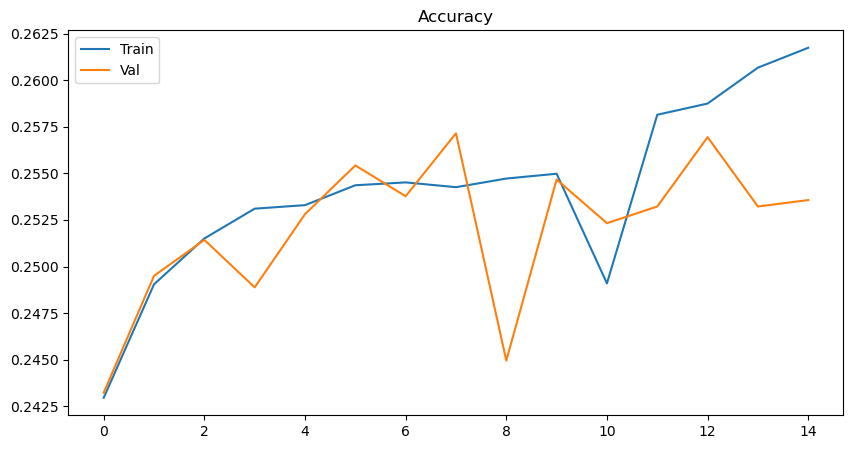

454/454 ━━━━━━━━━━━━━━━━━━━━ 852s 2s/step 


C:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                             precision    recall  f1-score   support

                             Apple__Healthy       0.00      0.00      0.00       487
                              Apple__Rotten       0.36      0.22      0.28       585
                            Banana__Healthy       0.56      0.03      0.05       399
                             Banana__Rotten       0.72      0.07      0.13       559
                        Bellpepper__Healthy       0.00      0.00      0.00       122
                         Bellpepper__Rotten       0.00      0.00      0.00       118
                                     Blight       0.00      0.00      0.00       229
                            Carrot__Healthy       0.00      0.00      0.00       123
                             Carrot__Rotten       0.00      0.00      0.00       115
                                Common_Rust       0.00      0.00      0.00       261
                          Cucumber__Healthy       0.00      0.00

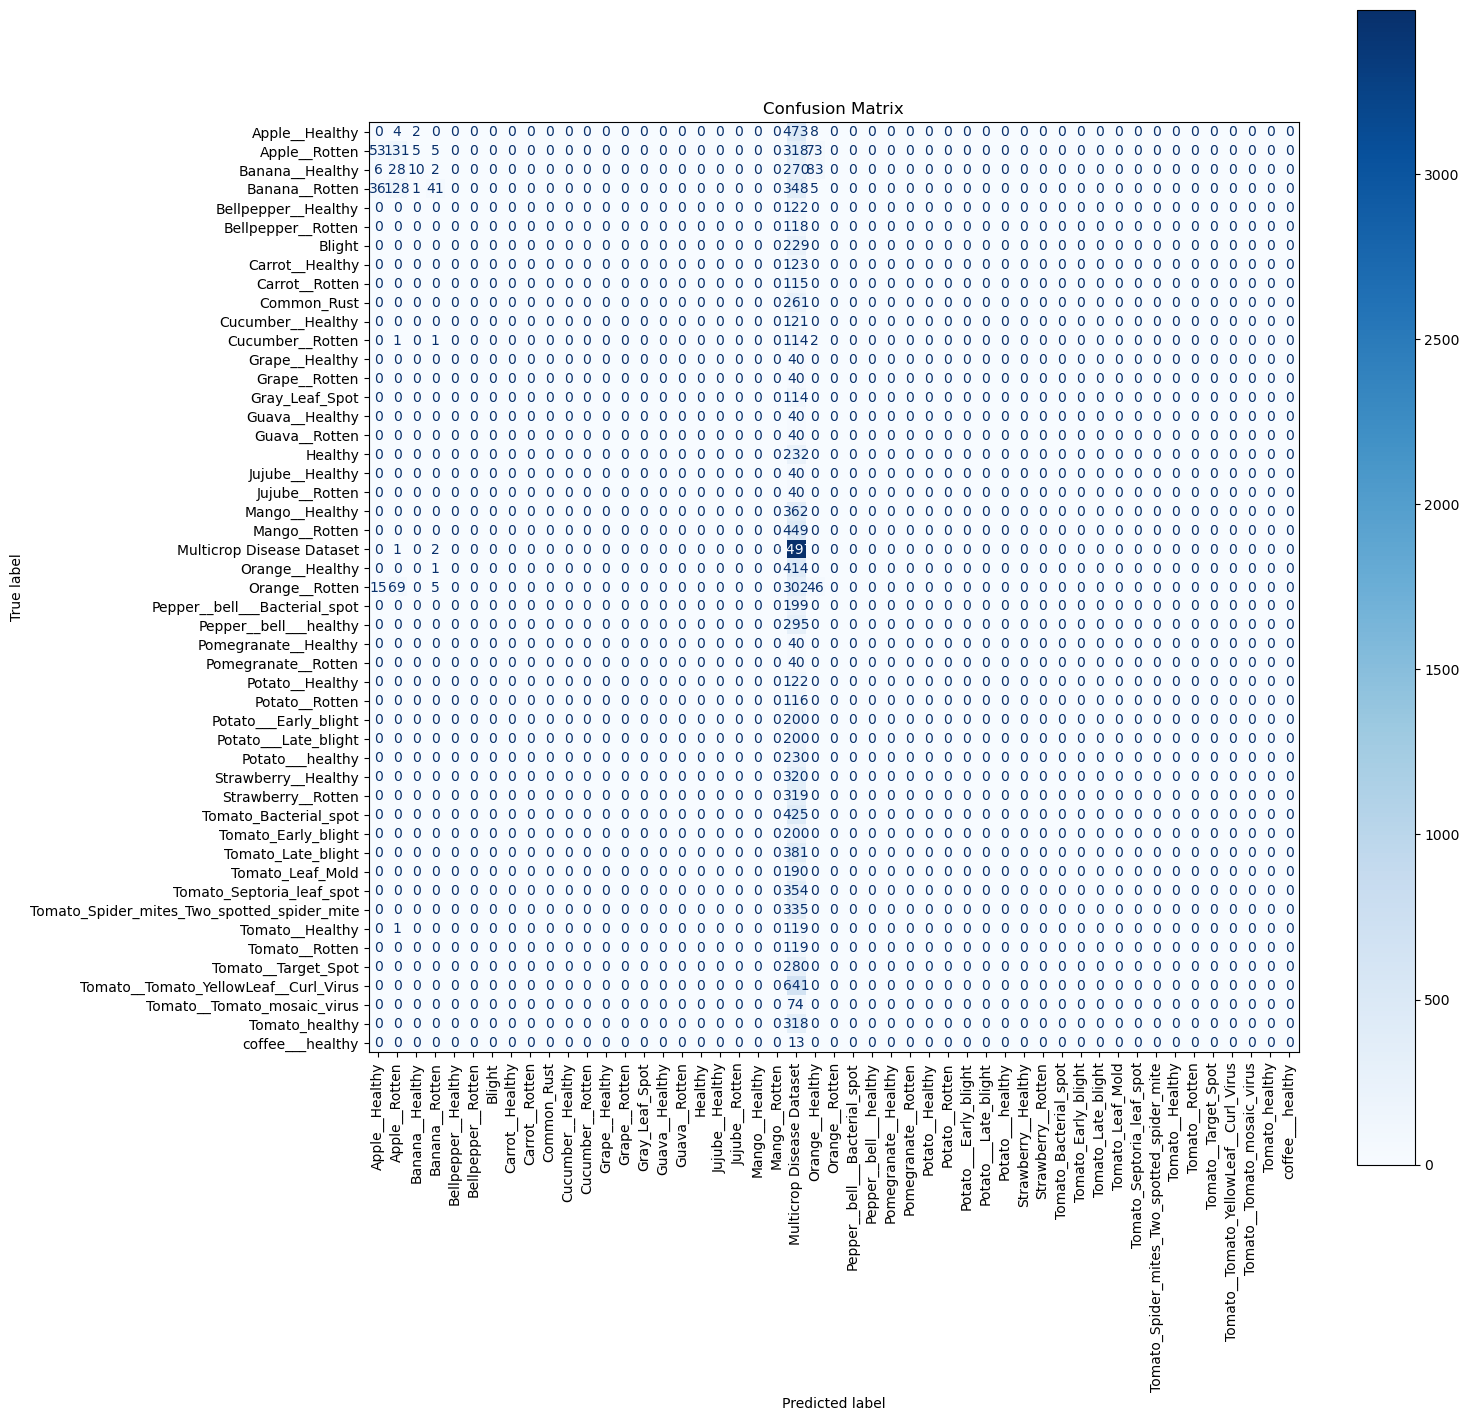

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import os

# ==================================================
# 1. SETUP & CONFIGURATION
# ==================================================
DATA_DIR = r"C:\Users\patta\Pictures\Screenshots\AgriGenius_AI2"
IMG_SIZE = (224, 224) # Optimized from 300x300 for 50% faster training
BATCH_SIZE = 32

# ==================================================
# 2. OPTIMIZED DATA PIPELINE
# ==================================================
datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2, rotation_range=20,
    zoom_range=0.2, horizontal_flip=True, width_shift_range=0.2, height_shift_range=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, 
    class_mode='categorical', subset='training', shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, 
    class_mode='categorical', subset='validation', shuffle=False
)

# ==================================================
# 3. EFFICIENTNETB3 ARCHITECTURE
# ==================================================
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ==================================================
# 4. TRAINING PHASES
# ==================================================
print("🚀 Phase 1: Initial Training Started")
history = model.fit(train_gen, validation_data=val_gen, epochs=10)

print("🚀 Phase 2: Fine Tuning Started")
base_model.trainable = True
# Only unfreeze the last 20 layers for better speed/stability
for layer in base_model.layers[:-20]: 
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
fine_history = model.fit(train_gen, validation_data=val_gen, epochs=5)

model.save("AgriVisionAI_EfficientNetB3_Optimized.h5")
print("✅ Model Saved")

# ==================================================
# 5. VISUALIZATION & EVALUATION
# ==================================================
# Combine history
acc = history.history['accuracy'] + fine_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_history.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.plot(acc, label="Train"); plt.plot(val_acc, label="Val"); plt.title("Accuracy")
plt.legend(); plt.show()

# Evaluation Metrics
val_gen.reset()
predictions = model.predict(val_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(15, 15))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=90, ax=ax)
plt.title("Confusion Matrix")
plt.show()

In [3]:
import os

DATA_DIR = r"C:\Users\patta\Pictures\Screenshots\AgriGenius_AI2"

for folder in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, folder)

    if os.path.isdir(path):
        count = len(os.listdir(path))
        print(f"{folder}: {count}")

Apple__Healthy: 2437
Apple__Rotten: 2930
Banana__Healthy: 2000
Banana__Rotten: 2800
Bellpepper__Healthy: 611
Bellpepper__Rotten: 591
Blight: 1146
Carrot__Healthy: 620
Carrot__Rotten: 580
Common_Rust: 1306
Cucumber__Healthy: 608
Cucumber__Rotten: 593
Grape__Healthy: 200
Grape__Rotten: 200
Gray_Leaf_Spot: 574
Guava__Healthy: 200
Guava__Rotten: 200
Healthy: 1162
Jujube__Healthy: 200
Jujube__Rotten: 200
Mango__Healthy: 1813
Mango__Rotten: 2247
Multicrop Disease Dataset: 17501
Orange__Healthy: 2075
Orange__Rotten: 2186
Pepper__bell___Bacterial_spot: 997
Pepper__bell___healthy: 1478
Pomegranate__Healthy: 200
Pomegranate__Rotten: 200
Potato__Healthy: 615
Potato__Rotten: 585
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 1152
Strawberry__Healthy: 1603
Strawberry__Rotten: 1596
Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_Late_blight: 1909
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Heal

Found 44153 images belonging to 48 classes.
Found 11017 images belonging to 48 classes.
🚀 Starting Initial Training...
Epoch 1/10
 719/1380 ━━━━━━━━━━━━━━━━━━━━ 19:20 2s/step - accuracy: 0.6040 - loss: 1.4034

C:\Users\patta\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 3121s 2s/step - accuracy: 0.7687 - loss: 0.7256 - val_accuracy: 0.8691 - val_loss: 0.4410
Epoch 2/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 3373s 2s/step - accuracy: 0.8535 - loss: 0.4204 - val_accuracy: 0.8954 - val_loss: 0.3316
Epoch 3/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 3336s 2s/step - accuracy: 0.8696 - loss: 0.3714 - val_accuracy: 0.9066 - val_loss: 0.2928
Epoch 4/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 3048s 2s/step - accuracy: 0.8788 - loss: 0.3436 - val_accuracy: 0.9110 - val_loss: 0.2904
Epoch 5/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 3079s 2s/step - accuracy: 0.8863 - loss: 0.3339 - val_accuracy: 0.9098 - val_loss: 0.3252
Epoch 6/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 3523s 3s/step - accuracy: 0.8948 - loss: 0.3060 - val_accuracy: 0.9092 - val_loss: 0.3071
Epoch 7/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 3202s 2s/step - accuracy: 0.8981 - loss: 0.2908 - val_accuracy: 0.9115 - val_loss: 0.3138
Epoch 8/10
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 3176s 2s/step - accuracy: 0.9028 - loss: 0.28

✅ Model Saved successfully!
345/345 ━━━━━━━━━━━━━━━━━━━━ 756s 2s/step 
                                             precision    recall  f1-score   support

                             Apple__Healthy       0.98      0.58      0.73       487
                              Apple__Rotten       0.86      0.98      0.91       585
                            Banana__Healthy       1.00      0.97      0.99       399
                             Banana__Rotten       0.98      1.00      0.99       559
                        Bellpepper__Healthy       0.86      0.93      0.89       122
                         Bellpepper__Rotten       0.77      0.78      0.78       118
                                     Blight       0.93      0.80      0.86       229
                            Carrot__Healthy       0.97      1.00      0.98       123
                             Carrot__Rotten       0.97      0.97      0.97       115
                                Common_Rust       0.96      0.99      0.98    

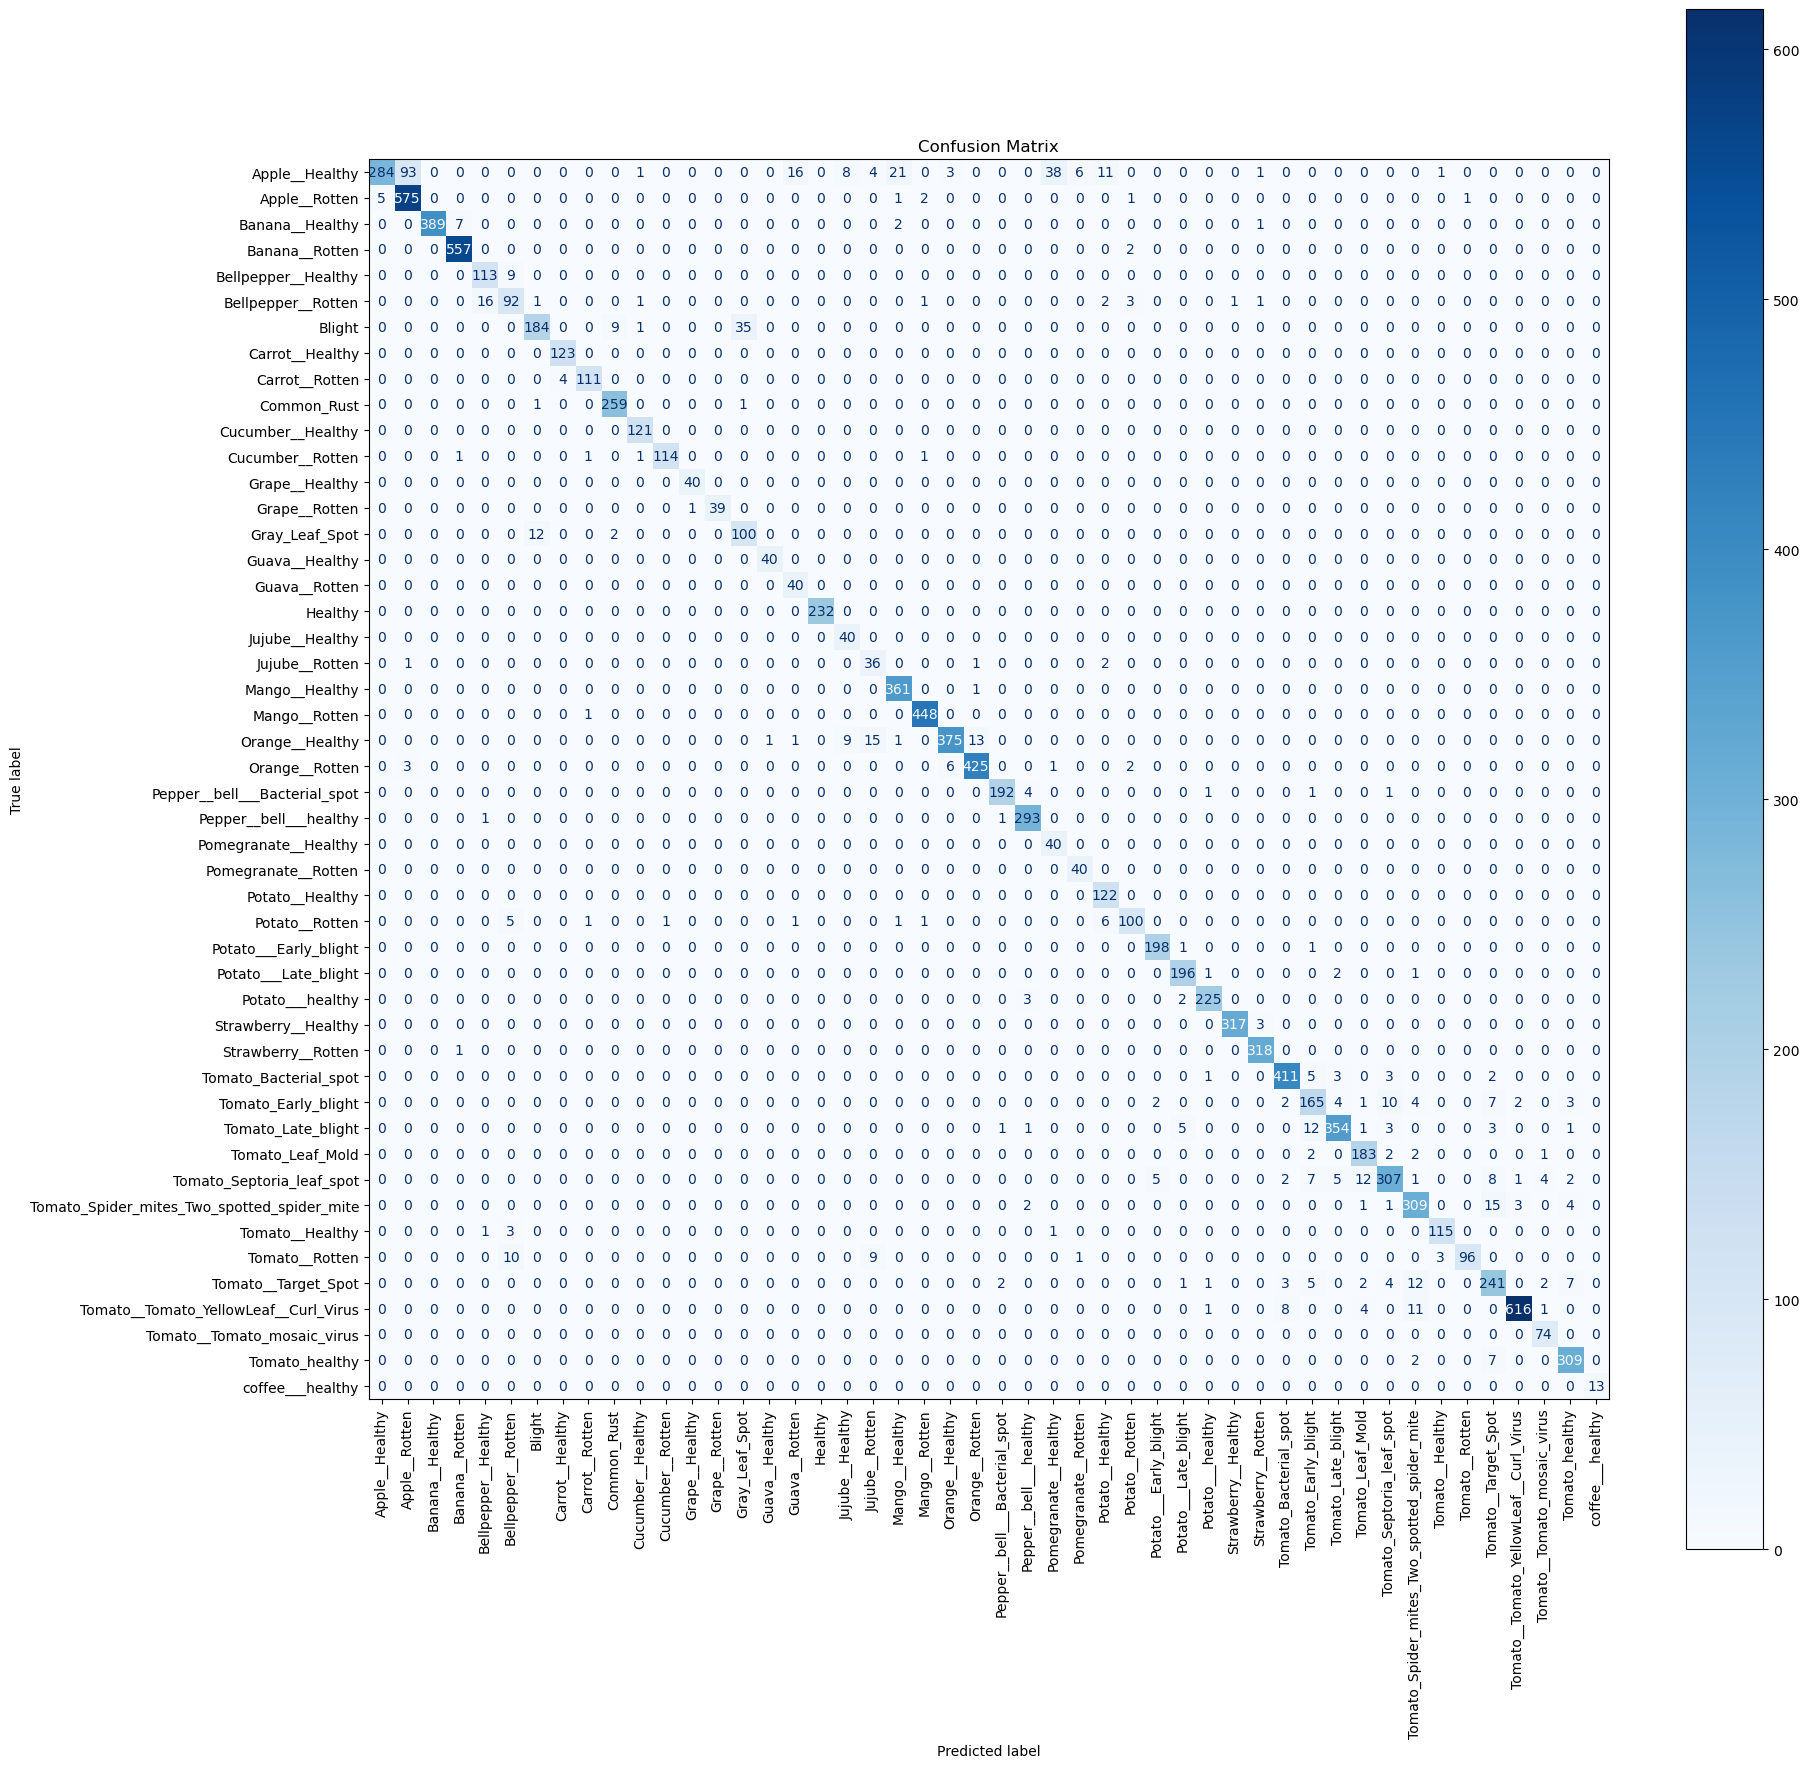

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input, EfficientNetB3
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==================================================
# 1. SETUP & DATA PIPELINE
# ==================================================
DATA_DIR = r"C:\Users\patta\Pictures\Screenshots\AgriGenius_AI2"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, 
    class_mode='categorical', subset='training', shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, 
    class_mode='categorical', subset='validation', shuffle=False
)

# ==================================================
# 2. CLASS WEIGHT BALANCING
# ==================================================
# Calculate weights to handle imbalance between classes
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(weights))

# ==================================================
# 3. MODEL ARCHITECTURE
# ==================================================
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ==================================================
# 4. TRAINING PHASES
# ==================================================
print("🚀 Starting Initial Training...")
history = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=10, 
    class_weight=class_weight_dict
)

print("🚀 Starting Fine Tuning...")
base_model.trainable = True
for layer in base_model.layers[:-20]: 
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
fine_history = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=5, 
    class_weight=class_weight_dict
)

model.save("AgriVisionAI_Final.h5")
print("✅ Model Saved successfully!")

# ==================================================
# 5. VISUALIZATION & EVALUATION
# ==================================================
val_gen.reset()
predictions = model.predict(val_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(20, 20))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=90, ax=ax)
plt.title("Confusion Matrix")
plt.show()

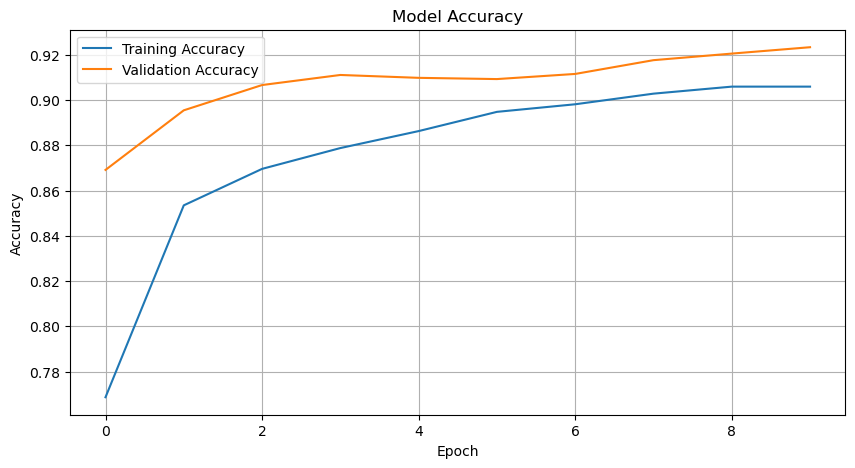

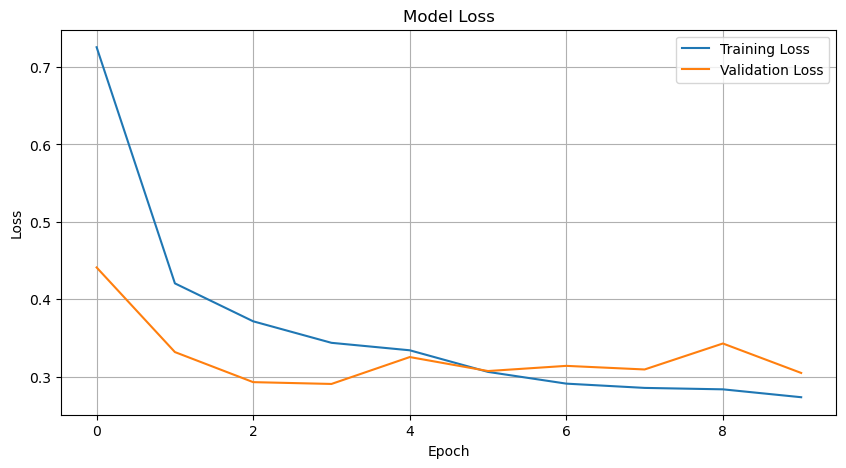

In [6]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig('visuals/accuracy_plot.png')
plt.show()

# Loss Plot
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.savefig('visuals/loss_plot.png')
plt.show()

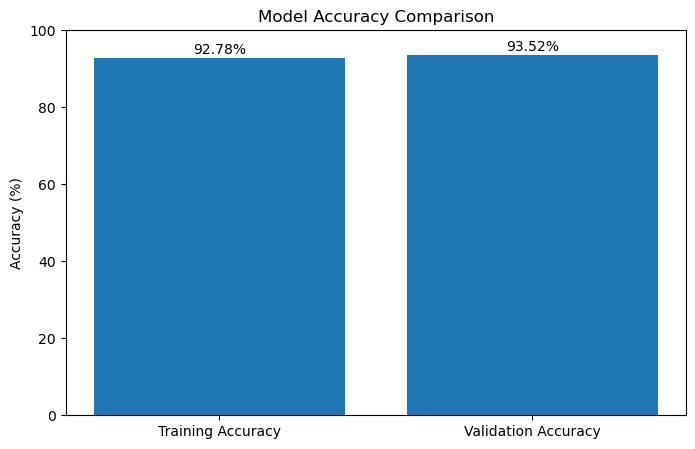

In [8]:
import matplotlib.pyplot as plt

training_accuracy = 92.78
validation_accuracy = 93.52

labels = ['Training Accuracy', 'Validation Accuracy']
values = [training_accuracy, validation_accuracy]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{bar.get_height():.2f}%',
        ha='center'
    )

plt.show()

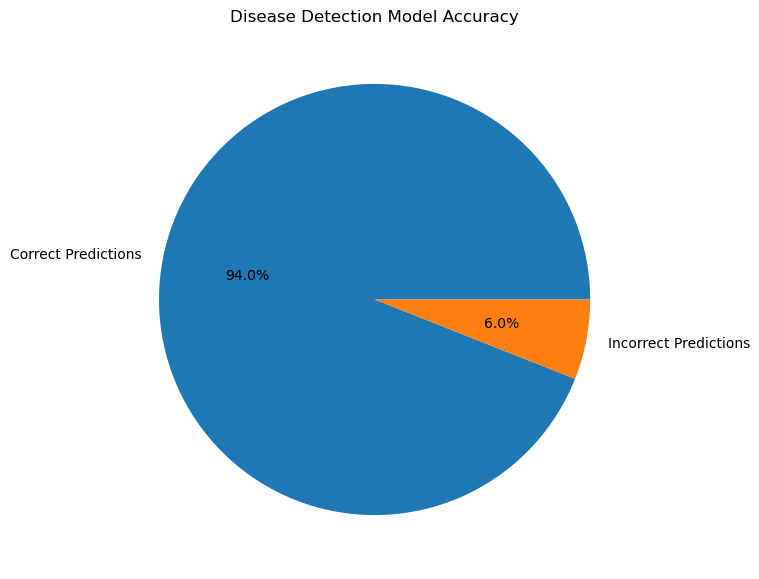

In [9]:
import matplotlib.pyplot as plt

accuracy = 94.0
error = 100 - accuracy

plt.figure(figsize=(7,7))

plt.pie(
    [accuracy, error],
    labels=['Correct Predictions', 'Incorrect Predictions'],
    autopct='%1.1f%%'
)

plt.title("Disease Detection Model Accuracy")

plt.show()